In [1]:
import os
import re
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import regression_functions as rf
from matplotlib.backends.backend_pdf import PdfPages
from figure_formatting import setup_figure, save_figure
from regression_functions import run_model_comparison as run_model
importlib.reload(rf)

<module 'regression_functions' from '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/code/regression_functions.py'>

In [2]:
import logging
import matplotlib as mpl

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

### Read in the data 

From `covbat_harmonization_ses.Rmd` followed by `abcd_prep_harmonized_dfs`

In [3]:
# ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
ROOT_DIR = Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
RESULTS_DIR = ROOT_DIR / "output_data" / "results"

dfA_macro = pd.read_csv(RESULTS_DIR / "dfA_macro_12_10.csv")
dfB_macro = pd.read_csv(RESULTS_DIR / "dfB_macro_12_10.csv")

dfA_NODDI = pd.read_csv(RESULTS_DIR / "dfA_NODDI_12_10.csv")
dfB_NODDI = pd.read_csv(RESULTS_DIR / "dfB_NODDI_12_10.csv")

dfA_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_12_10.csv")
dfB_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_12_10.csv")

dfA_DKI = pd.read_csv(RESULTS_DIR / "dfA_DKI_12_10.csv")
dfB_DKI = pd.read_csv(RESULTS_DIR / "dfB_DKI_12_10.csv")

dfA_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_DKI_12_10.csv")
dfB_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_DKI_12_10.csv")

In [4]:
print(dfA_macro.shape)
dfA_macro["matched_group"].value_counts()

(8174, 1136)


matched_group
2    4096
1    4078
Name: count, dtype: int64

In [5]:
# --- cleanup helper: drop mean columns, strip _median from remaining columns ---
def clean_bundle_columns(df):
    df = df.copy()

    bundle_cols_mean = [c for c in df.columns if c.startswith("bundle_") and "_mean" in c]
    df = df.drop(columns=bundle_cols_mean, errors="ignore")

    df = df.rename(columns=lambda c: c[:-len("_median")]
        if c.startswith("bundle_") and c.endswith("_median")
        else c)

    return df

dfs_to_clean = ["dfA_macro", "dfB_macro", "dfA_NODDI", "dfB_NODDI", "dfA_macro_plus_NODDI", "dfB_macro_plus_NODDI",
                "dfA_DKI", "dfB_DKI", "dfA_macro_plus_DKI", "dfB_macro_plus_DKI"]

for df_name in dfs_to_clean:
    globals()[df_name] = clean_bundle_columns(globals()[df_name])

In [6]:
tracts = sorted(set("_".join(c.split("_")[1:3]) for c in dfA_macro_plus_NODDI.columns if c.startswith("bundle_")))
print(len(tracts))

62


In [7]:
# --- helper to extract metric name from cleaned columns ---
def extract_metric_name(col):
    if not col.startswith("bundle_"):
        return None

    parts = col[len("bundle_"):].split("_")
    if len(parts) < 3: return None

    # first two parts are the bundle name, rest is the metric
    return "_".join(parts[2:])


# --- metric summaries after cleaning ---
metrics = sorted({m for c in dfA_macro_plus_NODDI.columns if (m := extract_metric_name(c)) is not None})

print(len(metrics))

20


### Mutlivariate Global Ridge Regression

NODDI as primary model, DKI as sensitivity analysis

Includes sensitivity analyses with brain volume correction (eTIV)

In [8]:
FIG4_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure4"
SUPPFIG6_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig6"
SUPPFIG7_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig7"
MODEL_DIR = ROOT_DIR / "output_data" / "model_outputs"
for d in [FIG4_DIR, SUPPFIG6_DIR, SUPPFIG7_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

target = "General_SES"

scenarios_top = [("NODDI", dfA_NODDI, dfB_NODDI), ("Macrostructure", dfA_macro, dfB_macro),
                 ("Macrostructure and NODDI", dfA_macro_plus_NODDI, dfB_macro_plus_NODDI)]

df_map_A = {"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI}
df_map_B = {"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI}

color_disc = {"NODDI": "#5D3FD3", "Macrostructure": "#0033A0", "Macrostructure and NODDI": "#C69214",
              "DKI": "#5D3FD3", "Macrostructure and DKI": "#C69214"}
color_repl = {"NODDI": "#B8A6F9", "Macrostructure": "#7BA6E6", "Macrostructure and NODDI": "#E9CB7F",
              "DKI": "#B8A6F9", "Macrostructure and DKI": "#E9CB7F"}

figure_configs = [{"tag":"Main", "save_dir":FIG4_DIR, "model_output_dir":MODEL_DIR,
                   "scenarios_top":[("NODDI", dfA_NODDI, dfB_NODDI), ("Macrostructure", dfA_macro, dfB_macro),
                                    ("Macrostructure and NODDI", dfA_macro_plus_NODDI, dfB_macro_plus_NODDI)],
                   "df_map_A":{"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI},
                   "df_map_B":{"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI},
                   "model_type":"ridge","n_components":17},
                  {"tag":"Supplement_PLS", "save_dir":SUPPFIG7_DIR, "model_output_dir":MODEL_DIR,
                   "scenarios_top":[("NODDI", dfA_NODDI, dfB_NODDI), ("Macrostructure", dfA_macro, dfB_macro),
                                    ("Macrostructure and NODDI", dfA_macro_plus_NODDI, dfB_macro_plus_NODDI)],
                   "df_map_A":{"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI},
                   "df_map_B":{"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI},
                   "model_type":"pls","n_components":17},
                  {"tag":"Supplement_DKI", "save_dir":SUPPFIG6_DIR, "model_output_dir":MODEL_DIR,
                   "scenarios_top":[("DKI", dfA_DKI, dfB_DKI), ("Macrostructure", dfA_macro, dfB_macro),
                                    ("Macrostructure and DKI", dfA_macro_plus_DKI, dfB_macro_plus_DKI)],
                   "df_map_A":{"DKI": dfA_DKI, "Macrostructure": dfA_macro, "Macrostructure and DKI": dfA_macro_plus_DKI},
                   "df_map_B":{"DKI": dfB_DKI, "Macrostructure": dfB_macro, "Macrostructure and DKI": dfB_macro_plus_DKI},
                   "model_type":"ridge","n_components":17}]

In [9]:
def run_one_figure(cfg):
    scenarios_top = cfg["scenarios_top"]; df_map_A, df_map_B = cfg["df_map_A"], cfg["df_map_B"]; model_type, n_comp, tag = cfg["model_type"], cfg["n_components"], cfg["tag"]
    save_dir = cfg["save_dir"]; model_output_dir = cfg.get("model_output_dir", save_dir)
    c_disc, c_repl = color_disc, color_repl
    xlab_fs = 7; scatter_top_pad_frac = 0.35; scatter_bottom_pad_frac = 0.18; lolli_top_pad = 0.10

    results = {}
    for name, df_A, df_B in scenarios_top:
        conf = ["age", "sex", "t1post_dwi_contrast"]; features = [c for c in df_A.columns if c.startswith("bundle_")]
        if model_type == "ridge": perf, _ = rf.run_model_comparison(features_subset=features, df_A=df_A, df_B=df_B, target=target, output_dir=model_output_dir, confounds=conf, model_type="ridge")
        else: perf, _ = rf.run_pls_model_exact(df_A, df_B, features_subset=features, target=target, confounds=conf, max_components=20, cv_tuning=True, fixed_n=n_comp)
        results[name] = perf

# ===================== FIGURES A–C: SCATTERS ===================== #
    W_MM = 160
    H_SCAT_MM = 70
    fig, axes = setup_figure(width_mm=W_MM, height_mm=H_SCAT_MM, margins_mm=(12, 6, 8, 8), nrows=1, ncols=3, sharex=True, sharey=True, axes_linewidth=0.8, axes_aspect="auto", sans_list="Helvetica", base_pt=7, label_pt=7, title_pt=7)
    scatter_axes = list(np.ravel(axes))
    
    titles = [n for n, _, _ in scenarios_top]
    for ax, (name, title) in zip(scatter_axes, zip([n for n, _, _ in scenarios_top], titles)):
        perf = results[name]
        y_true_disc, y_pred_disc = perf["y_true_A"], perf["y_pred_A"]
        y_true_repl, y_pred_repl = perf["y_true_B"], perf["y_pred_B"]
    
        ax.scatter(y_true_repl, y_pred_repl, color=c_repl[name], alpha=0.22, s=12, marker="^", label=fr"Replication ($r$={perf['r_B']:.2f})", zorder=2)
        ax.scatter(y_true_disc, y_pred_disc, color=c_disc[name], alpha=0.25, s=10, marker="o", label=fr"Discovery ($r$={perf['r_A']:.2f})", zorder=3)
    
        min_val = float(min(y_true_disc.min(), y_pred_disc.min(), y_true_repl.min(), y_pred_repl.min()))
        max_val = float(max(y_true_disc.max(), y_pred_disc.max(), y_true_repl.max(), y_pred_repl.max()))
    
        s1, i1 = np.polyfit(y_true_disc, y_pred_disc, 1)
        s2, i2 = np.polyfit(y_true_repl, y_pred_repl, 1)
    
        ax.plot([min_val, max_val], [s1 * min_val + i1, s1 * max_val + i1], color=c_disc[name], lw=1.2, zorder=4)
        ax.plot([min_val, max_val], [s2 * min_val + i2, s2 * max_val + i2], color=c_repl[name], lw=1.2, zorder=4)
    
        rng = max_val - min_val
        bottom_pad_frac = 0.18
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val - bottom_pad_frac * rng, max_val + scatter_top_pad_frac * rng)
    
        ax.set_title(title)
        ax.set_facecolor("white")
        ax.tick_params(axis="both", length=3, width=0.8, direction="out")
        ax.set_xlabel("")
        ax.set_ylabel("")
    
        handles, labels = ax.get_legend_handles_labels()
        order = [labels.index(next(l for l in labels if l.startswith("Discovery"))),
                 labels.index(next(l for l in labels if l.startswith("Replication")))]
        ax.legend([handles[i] for i in order], [labels[i] for i in order], frameon=False, fontsize=7, markerscale=1.2, loc="lower right")
    
        sns.despine(ax=ax, top=True, right=True)
    
    fig.supxlabel(r"Actual General Exposome ($\mathit{z}$)", fontsize=xlab_fs, y=0.001)
    scatter_axes[0].set_ylabel(r"Predicted General Exposome ($\mathit{z}$)")
    scatter_axes[0].yaxis.labelpad = 3.5
    
    save_figure(fig, save_dir / f"Figure_4_{tag}_Scatters.svg", autofit=False)
    fig.savefig(save_dir / f"Figure_4_{tag}_Scatters.png", dpi=600, bbox_inches="tight")
    plt.show()

    # ===================== FIGURE D: LOLLIPOP ===================== #
    H_LOLLI_MM = 60
    fig, ax_lolli = setup_figure(width_mm=W_MM, height_mm=H_LOLLI_MM, margins_mm=(10, 6, 14, 8), nrows=1, ncols=1, axes_linewidth=0.8, axes_aspect="auto", sans_list="Helvetica", base_pt=7, label_pt=7, title_pt=7)

    feature_sets = [n for n, _, _ in scenarios_top]
    disc_no, repl_no, disc_yes, repl_yes = [], [], [], []

    for fs in feature_sets:
        df_A = df_map_A[fs]; df_B = df_map_B[fs]
        conf_no = ["age", "sex", "t1post_dwi_contrast"]; conf_yes = ["age", "sex", "t1post_dwi_contrast", "eTIV"]
        feats = [c for c in df_A.columns if c.startswith("bundle_")]

        if model_type == "ridge":
            perf_no, _ = rf.run_model_comparison(features_subset=feats, df_A=df_A, df_B=df_B, target=target, output_dir=model_output_dir, confounds=conf_no, model_type="ridge")
            perf_yes, _ = rf.run_model_comparison(features_subset=feats, df_A=df_A, df_B=df_B, target=target, output_dir=model_output_dir, confounds=conf_yes, model_type="ridge")
        else:
            perf_no, _ = rf.run_pls_model_exact(df_A, df_B, features_subset=feats, target=target, confounds=conf_no, max_components=20, cv_tuning=False, fixed_n=n_comp)
            perf_yes, _ = rf.run_pls_model_exact(df_A, df_B, features_subset=feats, target=target, confounds=conf_yes, max_components=20, cv_tuning=False, fixed_n=n_comp)

        disc_no.append(perf_no["r_A"]); repl_no.append(perf_no["r_B"]); disc_yes.append(perf_yes["r_A"]); repl_yes.append(perf_yes["r_B"])

    lolli_df = pd.DataFrame({"Feature Set": feature_sets, "Discovery r (no TBV)": disc_no, "Replication r (no TBV)": repl_no, "Discovery r (+TBV)": disc_yes, "Replication r (+TBV)": repl_yes})
    print("\n=== LOLLIPOP VALUES (General SES Prediction) ==="); print(lolli_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    x = np.arange(len(feature_sets)); width = 0.20
    marker_noTIV, marker_yesTIV = 80, 110
    stem_lw, bottom_offset = 1.2, 0.12

    for i, fs in enumerate(feature_sets):
        dcol = c_disc[fs]; rcol = c_repl[fs]
        ax_lolli.vlines(x[i]-1.5*width, bottom_offset, disc_no[i], color=dcol, lw=stem_lw); ax_lolli.scatter(x[i]-1.5*width, disc_no[i], color=dcol, marker="o", s=marker_noTIV)
        ax_lolli.vlines(x[i]-0.5*width, bottom_offset, repl_no[i], color=rcol, lw=stem_lw); ax_lolli.scatter(x[i]-0.5*width, repl_no[i], color=rcol, marker="o", s=marker_noTIV)
        ax_lolli.vlines(x[i]+0.5*width, bottom_offset, disc_yes[i], color=dcol, lw=stem_lw); ax_lolli.scatter(x[i]+0.5*width, disc_yes[i], color=dcol, marker="s", s=marker_yesTIV)
        ax_lolli.vlines(x[i]+1.5*width, bottom_offset, repl_yes[i], color=rcol, lw=stem_lw); ax_lolli.scatter(x[i]+1.5*width, repl_yes[i], color=rcol, marker="s", s=marker_yesTIV)

    ax_lolli.set_xticks(x); ax_lolli.set_xticklabels(feature_sets, fontsize=7)
    ax_lolli.set_xlabel(""); ax_lolli.set_ylabel("Correlation ($r$)", fontsize=7)
    ax_lolli.tick_params(axis="both", length=3, width=0.8, direction="out")

    ymax = max(disc_no + repl_no + disc_yes + repl_yes)
    ax_lolli.set_ylim(bottom_offset, ymax + lolli_top_pad)

    legend_handles = [plt.Line2D([0], [0], color="black", marker="o", lw=0, markersize=6), plt.Line2D([0], [0], color="black", marker="s", lw=0, markersize=6)]
    ax_lolli.legend(legend_handles, ["without TBV correction", "with TBV correction"], frameon=False, fontsize=7, ncol=2, loc="upper left")

    ax_lolli.spines["top"].set_visible(False); ax_lolli.spines["right"].set_visible(False)
    sns.despine(ax=ax_lolli, top=True, right=True)

    save_figure(fig, save_dir / f"Figure_4_{tag}_Lollipop.svg", autofit=False)
    fig.savefig(save_dir / f"Figure_4_{tag}_Lollipop.png", dpi=600, bbox_inches="tight")
    plt.show()


=== Making Figure 3 (Main) ===


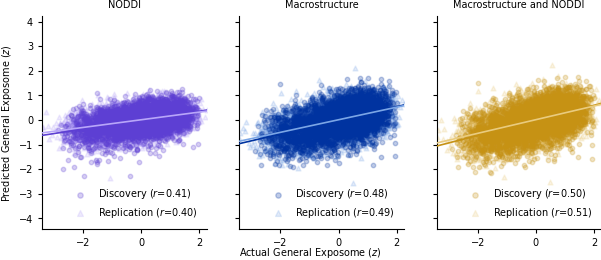


=== LOLLIPOP VALUES (General SES Prediction) ===
             Feature Set  Discovery r (no TBV)  Replication r (no TBV)  Discovery r (+TBV)  Replication r (+TBV)
                   NODDI                 0.410                   0.403               0.365                 0.356
          Macrostructure                 0.478                   0.486               0.415                 0.420
Macrostructure and NODDI                 0.501                   0.510               0.443                 0.446


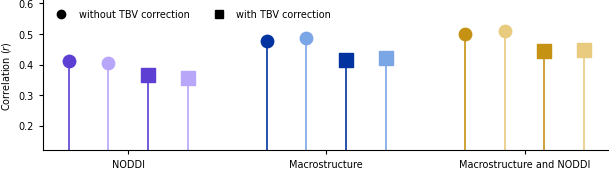


=== Making Figure 3 (Supplement_PLS) ===


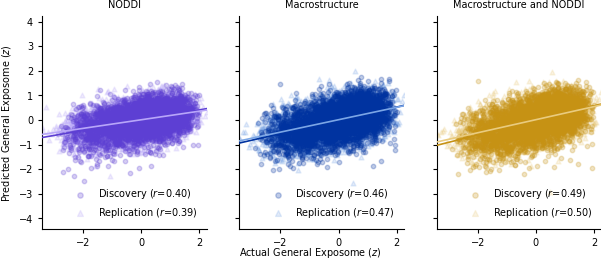


=== LOLLIPOP VALUES (General SES Prediction) ===
             Feature Set  Discovery r (no TBV)  Replication r (no TBV)  Discovery r (+TBV)  Replication r (+TBV)
                   NODDI                 0.400                   0.393               0.352                 0.345
          Macrostructure                 0.460                   0.467               0.400                 0.404
Macrostructure and NODDI                 0.474                   0.484               0.415                 0.423


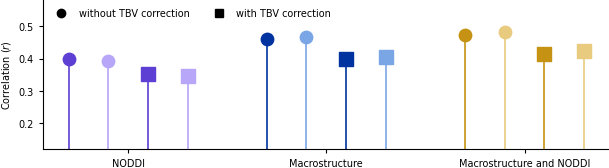


=== Making Figure 3 (Supplement_DKI) ===


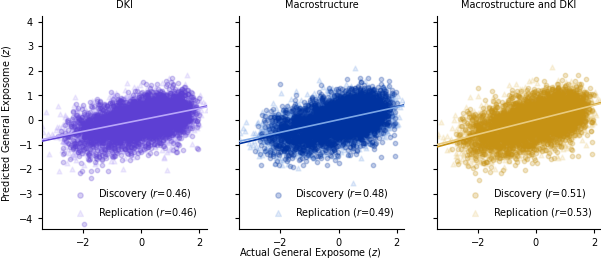


=== LOLLIPOP VALUES (General SES Prediction) ===
           Feature Set  Discovery r (no TBV)  Replication r (no TBV)  Discovery r (+TBV)  Replication r (+TBV)
                   DKI                 0.457                   0.461               0.407                 0.417
        Macrostructure                 0.478                   0.486               0.415                 0.420
Macrostructure and DKI                 0.514                   0.528               0.459                 0.462


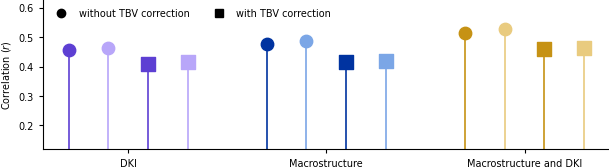

In [10]:
for cfg in figure_configs:
    print(f"\n=== Making Figure 3 ({cfg['tag']}) ===")
    run_one_figure(cfg)

### Permutation Test

In [11]:
FIG4_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure4"
SUPPFIG6_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig6"
SUPPFIG7_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig7"
MODEL_DIR = ROOT_DIR / "output_data" / "model_outputs"
for d in [FIG4_DIR, SUPPFIG6_DIR, SUPPFIG7_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

perm_configs = [{"tag":"Main", "save_dir":FIG4_DIR, "perm_dir":FIG4_DIR / "permutation_results",
                 "df_map_A":{"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI},
                 "df_map_B":{"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI},
                 "feature_prefix_map":{"NODDI": ("bundle_",), "Macrostructure": ("bundle_",), "Macrostructure and NODDI": ("bundle_",)},
                 "model_type":"ridge"},
                {"tag":"Supplement_PLS", "save_dir":SUPPFIG7_DIR, "perm_dir":SUPPFIG7_DIR / "permutation_results",
                 "df_map_A":{"NODDI": dfA_NODDI, "Macrostructure": dfA_macro, "Macrostructure and NODDI": dfA_macro_plus_NODDI},
                 "df_map_B":{"NODDI": dfB_NODDI, "Macrostructure": dfB_macro, "Macrostructure and NODDI": dfB_macro_plus_NODDI},
                 "feature_prefix_map":{"NODDI": ("bundle_",), "Macrostructure": ("bundle_",), "Macrostructure and NODDI": ("bundle_",)},
                 "model_type":"pls"},
                {"tag":"Supplement_DKI", "save_dir":SUPPFIG6_DIR, "perm_dir":SUPPFIG6_DIR / "permutation_results",
                 "df_map_A":{"DKI": dfA_DKI, "Macrostructure": dfA_macro, "Macrostructure and DKI": dfA_macro_plus_DKI},
                 "df_map_B":{"DKI": dfB_DKI, "Macrostructure": dfB_macro, "Macrostructure and DKI": dfB_macro_plus_DKI},
                 "feature_prefix_map":{"DKI": ("bundle_",), "Macrostructure": ("bundle_",), "Macrostructure and DKI": ("bundle_",)},
                 "model_type":"ridge"}]

for cfg in perm_configs: cfg["perm_dir"].mkdir(parents=True, exist_ok=True)

n_perm = 1000
target = "General_SES"
confounds = ['age', 'sex', "t1post_dwi_contrast"]

for cfg in perm_configs:
    tag = cfg["tag"]; save_dir = cfg["save_dir"]; perm_dir = cfg["perm_dir"]; df_map_A = cfg["df_map_A"]; df_map_B = cfg["df_map_B"]
    feature_prefix_map = cfg["feature_prefix_map"]; model_type = cfg["model_type"]

    print(f"\n=== {tag} | model_type={model_type} ===")

    for fs in df_map_A.keys():
        print(f"\nRunning permutations for: {fs} ({model_type}, no TBV)")
        dfA, dfB = df_map_A[fs], df_map_B[fs]

        prefixes = feature_prefix_map[fs]
        features = [c for c in dfA.columns if any(c.startswith(p) for p in prefixes)]

        A_train = dfA[dfA["matched_group"] == 1].copy()
        A_test  = dfA[dfA["matched_group"] == 2].copy()
        B_train = dfB[dfB["matched_group"] == 2].copy()
        B_test  = dfB[dfB["matched_group"] == 1].copy()

        print("  discovery permutations...")
        X_A_std, y_A_std, X_B_std, y_B_std = rf.prepare_direction_data(A_train, A_test, features, confounds, target)
        r_true_A, null_A, p_A = rf.permutation_test(X_train=X_A_std, y_train=y_A_std, X_test=X_B_std, y_test=y_B_std,
                                                    n_permutations=n_perm, model_type=model_type)
        np.savez(perm_dir / f"{fs}_{model_type}_noTBV_discovery_perm.npz", r_true=r_true_A, null=null_A, p_val=p_A)

        print("  replication permutations...")
        X_B2_std, y_B2_std, X_A2_std, y_A2_std = rf.prepare_direction_data(B_train, B_test, features, confounds, target)
        r_true_B, null_B, p_B = rf.permutation_test(X_train=X_B2_std, y_train=y_B2_std, X_test=X_A2_std, y_test=y_A2_std,
                                                    n_permutations=n_perm, model_type=model_type)
        np.savez(perm_dir / f"{fs}_{model_type}_noTBV_replication_perm.npz", r_true=r_true_B, null=null_B, p_val=p_B)

        print(f"saved {fs} {model_type} noTBV permutation results.")
        print("  discovery:", f"r_true={r_true_A:.3f}", f"p={p_A:.4g}")
        print("  replication:", f"r_true={r_true_B:.3f}", f"p={p_B:.4g}")


=== Main | model_type=ridge ===

Running permutations for: NODDI (ridge, no TBV)
  discovery permutations...
  replication permutations...
saved NODDI ridge noTBV permutation results.
  discovery: r_true=0.403 p=0.000999
  replication: r_true=0.410 p=0.000999

Running permutations for: Macrostructure (ridge, no TBV)
  discovery permutations...
  replication permutations...
saved Macrostructure ridge noTBV permutation results.
  discovery: r_true=0.486 p=0.000999
  replication: r_true=0.478 p=0.000999

Running permutations for: Macrostructure and NODDI (ridge, no TBV)
  discovery permutations...
  replication permutations...
saved Macrostructure and NODDI ridge noTBV permutation results.
  discovery: r_true=0.510 p=0.000999
  replication: r_true=0.501 p=0.000999

=== Supplement_PLS | model_type=pls ===

Running permutations for: NODDI (pls, no TBV)
  discovery permutations...
  replication permutations...
saved NODDI pls noTBV permutation results.
  discovery: r_true=0.393 p=0.000999
 

### Plot Permutation Results


=== Main | model_type=ridge ===
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_NODDI_combined_Main.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_NODDI_combined_Main.png


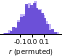

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_Macrostructure_combined_Main.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_Macrostructure_combined_Main.png


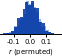

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_Macrostructure and NODDI_combined_Main.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure4/perm_inset_Macrostructure and NODDI_combined_Main.png


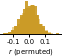


=== Supplement_PLS | model_type=pls ===
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_NODDI_combined_Supplement_PLS.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_NODDI_combined_Supplement_PLS.png


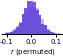

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_Macrostructure_combined_Supplement_PLS.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_Macrostructure_combined_Supplement_PLS.png


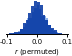

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_Macrostructure and NODDI_combined_Supplement_PLS.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig7/perm_inset_Macrostructure and NODDI_combined_Supplement_PLS.png


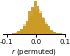


=== Supplement_DKI | model_type=ridge ===
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_DKI_combined_Supplement_DKI.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_DKI_combined_Supplement_DKI.png


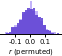

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_Macrostructure_combined_Supplement_DKI.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_Macrostructure_combined_Supplement_DKI.png


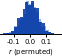

[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_Macrostructure and DKI_combined_Supplement_DKI.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/suppfig6/perm_inset_Macrostructure and DKI_combined_Supplement_DKI.png


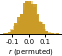

In [15]:
W_MM, H_MM = 15.75, 13.75
bins = 20
xticks = [-0.1, 0.0, 0.1]
xticklabels = ["-0.1", "0.0", "0.1"]

plot_perm_configs = [{"tag":"Main", "save_dir":FIG4_DIR, "perm_dir":FIG4_DIR / "permutation_results",
                      "feature_sets":["NODDI", "Macrostructure", "Macrostructure and NODDI"], "model_type":"ridge"},
                     {"tag":"Supplement_PLS", "save_dir":SUPPFIG7_DIR, "perm_dir":SUPPFIG7_DIR / "permutation_results",
                      "feature_sets":["NODDI", "Macrostructure", "Macrostructure and NODDI"], "model_type":"pls"},
                     {"tag":"Supplement_DKI", "save_dir":SUPPFIG6_DIR, "perm_dir":SUPPFIG6_DIR / "permutation_results",
                      "feature_sets":["DKI", "Macrostructure", "Macrostructure and DKI"], "model_type":"ridge"}]

for cfg in plot_perm_configs:
    tag = cfg["tag"]; save_dir = cfg["save_dir"]; perm_dir = cfg["perm_dir"]; feature_sets = cfg["feature_sets"]; model_type = cfg["model_type"]
    print(f"\n=== {tag} | model_type={model_type} ===")

    for fs in feature_sets:
        disc_path = perm_dir / f"{fs}_{model_type}_noTBV_discovery_perm.npz"
        repl_path = perm_dir / f"{fs}_{model_type}_noTBV_replication_perm.npz"

        null_A = np.load(disc_path)["null"]
        null_B = np.load(repl_path)["null"]

        fig, ax = setup_figure(width_mm=W_MM, height_mm=H_MM, margins_mm=(0, 0, 5, 0),
                               nrows=1, ncols=1, axes_linewidth=0.7,
                               axes_aspect="auto", base_pt=5, label_pt=5, title_pt=5)

        sns.histplot(null_B, bins=bins, color=color_repl[fs], edgecolor=None, alpha=0.85, ax=ax)
        sns.histplot(null_A, bins=bins, color=color_disc[fs], edgecolor=None, alpha=0.85, ax=ax)

        ax.yaxis.set_visible(False)
        sns.despine(left=True, right=True, top=True, ax=ax)

        ax.set_xlabel(r"$r$ (permuted)")
        ax.xaxis.labelpad = 1

        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.tick_params(axis="x", pad=1, length=2.5, width=0.7, direction="out")

        svg_path = save_dir / f"perm_inset_{fs}_combined_{tag}.svg"
        png_path = save_dir / f"perm_inset_{fs}_combined_{tag}.png"
        save_figure(fig, svg_path, autofit=False)
        fig.savefig(png_path, dpi=600, bbox_inches="tight")

        print(f"[SAVE] → {svg_path}")
        print(f"[SAVE] → {png_path}")
        plt.show()

### Supplementary Figure 5 - compare multivariate Haufe weights to univariate partial r values

In [16]:
# extract haufe weights from main analysis to compare to univariate partial r values

target = "General_SES"
df_A = dfA_macro_plus_NODDI
df_B = dfB_macro_plus_NODDI
conf = ["age", "sex", "t1post_dwi_contrast"]
features = [c for c in df_A.columns if c.startswith("bundle_")]

# Load partial r CSV
SUPPFIG9_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig9"
SUPPFIG9_DIR.mkdir(parents=True, exist_ok=True)
partial_r = pd.read_csv(SUPPFIG9_DIR / "partial_r_General_SES_NODDI_etivFalse.csv")


perf, haufe_df = rf.run_model_comparison(
    features_subset=features,
    df_A=df_A,
    df_B=df_B,
    target=target,
    output_dir=SUPPFIG9_DIR,
    confounds=conf,
    model_type="ridge"
)

# discovery group A: compare to A→B Haufe
partial_r_A = partial_r.query("group == 'A'")[["feature", "partial_r"]].copy()
merged_A = haufe_df.merge(partial_r_A, on="feature", how="inner", validate="one_to_one")
print(f"Merged A: {merged_A.shape[0]} / {haufe_df.shape[0]}")

# discovery group B: compare to B→A Haufe
partial_r_B = partial_r.query("group == 'B'")[["feature", "partial_r"]].copy()
merged_B = haufe_df.merge(partial_r_B, on="feature", how="inner", validate="one_to_one")
print(f"Merged B: {merged_B.shape[0]} / {haufe_df.shape[0]}")


Merged A: 1240 / 1240
Merged B: 1240 / 1240


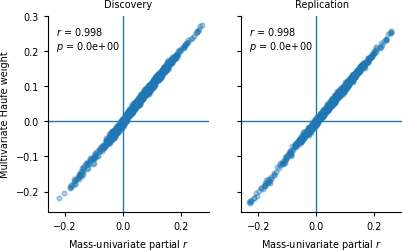

In [17]:
# extract data
SUPPFIG5_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig5"
SUPPFIG5_DIR.mkdir(parents=True, exist_ok=True)

xA = merged_A["partial_r"].to_numpy()
yA = merged_A["haufe_weight_AtoB"].to_numpy()
rA, pA = pearsonr(xA, yA)

xB = merged_B["partial_r"].to_numpy()
yB = merged_B["haufe_weight_BtoA"].to_numpy()
rB, pB = pearsonr(xB, yB)

# set up figure
fig, axes = setup_figure(width_mm=100, height_mm=50,  nrows=1, ncols=2, margins_mm=(10, 0, 0, 0), sharex=True, sharey=True)

axA, axB = axes.ravel()

# ---------- Panel A: A → B ----------
axA.scatter(xA, yA, alpha=0.35, s=12)
axA.axhline(0, lw=1)
axA.axvline(0, lw=1)

axA.set_title("Discovery")
axA.set_xlabel("Mass-univariate partial $r$")
axA.set_ylabel("Multivariate Haufe weight")

axA.text(0.05, 0.95, f"$r$ = {rA:.3f}\n$p$ = {pA:.1e}", transform=axA.transAxes, ha="left", va="top", fontsize=7)

# ---------- Panel B: B → A ----------
axB.scatter(xB, yB, alpha=0.35, s=12)
axB.axhline(0, lw=1)
axB.axvline(0, lw=1)

axB.set_title("Replication")
axB.set_xlabel("Mass-univariate partial $r$")
axB.set_ylabel("")

axB.text(0.05, 0.95, f"$r$ = {rB:.3f}\n$p$ = {pB:.1e}", transform=axB.transAxes, ha="left", va="top", fontsize=7)

for ax in (axA, axB):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", length=3, width=0.8, direction="out")

plt.show()
save_figure(fig, SUPPFIG5_DIR / "haufe_vs_partialr.svg", autofit=False)